## Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

# Import custom modules
import sys

sys.path.insert(0, "../")


# Set random seed
RANDOM_SEED = 1234
np.random.seed(RANDOM_SEED)

# Configure plotting
import seaborn as sns
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")


## Data Loading Functions

In [2]:
df = pd.read_csv("../data/diabetic_data.csv")

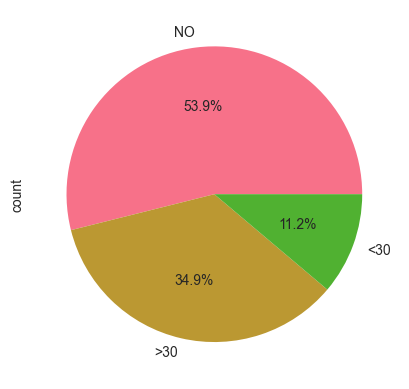

In [3]:
df["readmitted"].value_counts() / len(df)
counts = df["readmitted"].value_counts()

percentages = counts * 100 / len(df)

fig, ax = plt.subplots()
percentages.plot(kind="pie", ax=ax, autopct="%1.1f%%")
plt.show()

In [4]:
# define outcome variable
df = df.replace({"readmitted": {"<30": 1, ">30": 0, "NO": 0}})
print(df["readmitted"].value_counts())

readmitted
0    90409
1    11357
Name: count, dtype: int64


/var/folders/6v/6n8wfh_11jxg4d9zx6jqhzqh0000gn/T/ipykernel_95032/1643966228.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"readmitted": {"<30": 1, ">30": 0, "NO": 0}})


In [5]:
def age_to_midpoint(age_bucket):
    """
    Convert age buckets like "[70-80)" to numeric midpoint (75).

    Args:
        age_bucket: String representing age range

    Returns:
        Numeric midpoint of the age range
    """
    if pd.isna(age_bucket):
        return np.nan
    try:
        lo, hi = age_bucket.strip("[]").split("-")
        lo = int(lo)
        hi = int(hi.strip(")"))
        return (lo + hi) / 2
    except Exception:
        return np.nan

In [6]:
# 1. Process age to continuous midpoint
df["age_mid"] = df["age"].apply(age_to_midpoint)
df.drop(columns=["age"], inplace=True)

In [7]:
# drop columns that are majority missing
df = df.drop(["weight", "payer_code", "medical_specialty"], axis=1)

In [8]:
# drop rows with missing values in diagnosis columns
df = df.dropna(subset=["diag_1", "diag_2", "diag_3"])
df = df.drop(df.loc[df["diag_1"] == "?"].index, axis=0)
df = df.drop(df.loc[df["diag_2"] == "?"].index, axis=0)
df = df.drop(df.loc[df["diag_3"] == "?"].index, axis=0)

# drop missing values in race column
df = df.dropna(subset=["race"])
df = df.drop(df.loc[df["race"] == "?"].index, axis=0)

# drop missing values in gender column
df = df.drop(df.loc[df["gender"] == "Unknown/Invalid"].index, axis=0)

# drop discharge_disposition_id values that are not relevant for this analysis (expired, hospice, etc.)
df = df.drop(
    df.loc[df["discharge_disposition_id"].isin([11, 19, 20, 21, 25, 26])].index, axis=0
)

# drop drugs with same values for all patients (no predictive power)
df = df.drop(["citoglipton", "examide"], axis=1)


In [9]:
# Check for missing values in the data
for col in df.columns:
    if df[col].dtype == object:
        print(col, df[col][df[col] == "?"].count())

print("gender", df["gender"][df["gender"] == "Unknown/Invalid"].count())

race 0
gender 0
diag_1 0
diag_2 0
diag_3 0
max_glu_serum 0
A1Cresult 0
metformin 0
repaglinide 0
nateglinide 0
chlorpropamide 0
glimepiride 0
acetohexamide 0
glipizide 0
glyburide 0
tolbutamide 0
pioglitazone 0
rosiglitazone 0
acarbose 0
miglitol 0
troglitazone 0
tolazamide 0
insulin 0
glyburide-metformin 0
glipizide-metformin 0
glimepiride-pioglitazone 0
metformin-rosiglitazone 0
metformin-pioglitazone 0
change 0
diabetesMed 0
gender 0


In [10]:
df.shape

(95495, 45)

# Feature Engineering #

In [11]:
# Create service utilization feature (sum of outpatient, emergency, inpatient visits)
df["service_utilization"] = (
    df["number_outpatient"].fillna(0)
    + df["number_emergency"].fillna(0)
    + df["number_inpatient"].fillna(0)
)

In [12]:
# Create medication change feature
keys = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "insulin",
    "glyburide-metformin",
    "tolazamide",
    "metformin-pioglitazone",
    "metformin-rosiglitazone",
    "glimepiride-pioglitazone",
    "glipizide-metformin",
    "troglitazone",
    "tolbutamide",
    "acetohexamide",
]
for col in keys:
    colname = str(col) + "temp"
    df[colname] = df[col].apply(lambda x: 0 if (x == "No" or x == "Steady") else 1)
df["numchange"] = 0
for col in keys:
    colname = str(col) + "temp"
    df["numchange"] = df["numchange"] + df[colname]
    del df[colname]

df["numchange"].value_counts()

numchange
0    69444
1    24679
2     1262
3      105
4        5
Name: count, dtype: int64

In [13]:
# encode medication change, gender and diabetesMed to binary
df["change"] = df["change"].replace("Ch", 1)
df["change"] = df["change"].replace("No", 0)
df["gender"] = df["gender"].replace("Male", 1)
df["gender"] = df["gender"].replace("Female", 0)
df["diabetesMed"] = df["diabetesMed"].replace("Yes", 1)
df["diabetesMed"] = df["diabetesMed"].replace("No", 0)
# keys are the same as before
for col in keys:
    df[col] = df[col].replace("No", 0)
    df[col] = df[col].replace("Steady", 1)
    df[col] = df[col].replace("Up", 1)
    df[col] = df[col].replace("Down", 1)

/var/folders/6v/6n8wfh_11jxg4d9zx6jqhzqh0000gn/T/ipykernel_95032/2387615698.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["change"] = df["change"].replace("No", 0)
/var/folders/6v/6n8wfh_11jxg4d9zx6jqhzqh0000gn/T/ipykernel_95032/2387615698.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"] = df["gender"].replace("Female", 0)
/var/folders/6v/6n8wfh_11jxg4d9zx6jqhzqh0000gn/T/ipykernel_95032/2387615698.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. 

In [14]:
# A1Cresult: 0=None/Missing, 1=Normal, 2=High
df["A1Cresult"] = df["A1Cresult"].replace({">7": 2, ">8": 2, "Norm": 1, "None": 0})
df["A1Cresult"] = df["A1Cresult"].fillna(0)

# max_glu_serum: 0=None/Missing, 1=Normal, 2=High
df["max_glu_serum"] = df["max_glu_serum"].replace({">200": 2, ">300": 2, "Norm": 1, "None": 0})
df["max_glu_serum"] = df["max_glu_serum"].fillna(0)

/var/folders/6v/6n8wfh_11jxg4d9zx6jqhzqh0000gn/T/ipykernel_95032/2218200841.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["A1Cresult"] = df["A1Cresult"].replace({">7": 2, ">8": 2, "Norm": 1, "None": 0})
/var/folders/6v/6n8wfh_11jxg4d9zx6jqhzqh0000gn/T/ipykernel_95032/2218200841.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["max_glu_serum"] = df["max_glu_serum"].replace({">200": 2, ">300": 2, "Norm": 1, "None": 0})


## Diagnosis Processing Functions

In [15]:
def diagnosis_to_category(diag_code):
    """
    Map diagnosis codes to broader categories.

    Args:
        diag_code: Diagnosis code as string or number

    Returns:
        Diagnosis category as int (1-9, or 0 for Unknown)
    """
    if pd.isna(diag_code) or diag_code == "?" or diag_code is None:
        return 0  # Unknown

    try:
        # Handle string codes that start with V or E
        if isinstance(diag_code, str):
            if diag_code.startswith("V") or diag_code.startswith("E"):
                return 9  # Supplementary
            # Try to convert to float for numeric comparison
            code = float(diag_code)
        else:
            code = float(diag_code)

        # Map to categories based on ICD-9 code ranges
        if 390 <= code <= 459 or code == 785:
            return 1  # Circulatory
        elif 460 <= code <= 519 or code == 786:
            return 2  # Respiratory
        elif 520 <= code <= 579 or code == 787:
            return 3  # Digestive
        elif 250 <= code < 251:
            return 4  # Diabetes
        elif 800 <= code <= 999:
            return 5  # Injury
        elif 710 <= code <= 739:
            return 6  # Musculoskeletal
        elif 580 <= code <= 629 or code == 788:
            return 7  # Genitourinary
        elif 140 <= code <= 239:
            return 8  # Neoplasms
        else:
            return 9  # Other

    except (ValueError, TypeError):
        return 9  # Other for any conversion errors


# Create diagnosis categories
# This mirrors the diagnosis categorization from the original study
df["diag_1_cat"] = df["diag_1"].apply(diagnosis_to_category)
df["diag_2_cat"] = df["diag_2"].apply(diagnosis_to_category)
df["diag_3_cat"] = df["diag_3"].apply(diagnosis_to_category)

print("Diagnosis categories created:")
print(f"diag_1_cat distribution:\n{df['diag_1_cat'].value_counts().sort_index()}")
print(f"\ndiag_2_cat distribution:\n{df['diag_2_cat'].value_counts().sort_index()}")
print(f"\ndiag_3_cat distribution:\n{df['diag_3_cat'].value_counts().sort_index()}")

# Category mapping for reference:
# 0: Unknown/Missing
# 1: Circulatory (390-459, 785)
# 2: Respiratory (460-519, 786)
# 3: Digestive (520-579, 787)
# 4: Diabetes (250-250.99)
# 5: Injury (800-999)
# 6: Musculoskeletal (710-739)
# 7: Genitourinary (580-629, 788)
# 8: Neoplasms (140-239)
# 9: Other/Supplementary

Diagnosis categories created:
diag_1_cat distribution:
diag_1_cat
1    28800
2    13527
3     8999
4     7818
5     6548
6     4683
7     4879
8     3155
9    17086
Name: count, dtype: int64

diag_2_cat distribution:
diag_2_cat
1    30304
2    10163
3     3950
4    11634
5     2268
6     1700
7     8005
8     2387
9    25084
Name: count, dtype: int64

diag_3_cat distribution:
diag_3_cat
1    28842
2     6873
3     3770
4    16374
5     1830
6     1828
7     6319
8     1728
9    27931
Name: count, dtype: int64


In [16]:
# Create one-hot encoding for PRIMARY diagnosis (most clinically important)
print("Creating primary diagnosis one-hot encoding...")
df_primary = pd.get_dummies(df['diag_1_cat'], prefix='primary_diag', dtype=int)
df = pd.concat([df, df_primary], axis=1)

# Create binary indicators for ANY diagnosis position (captures comorbidities)
# Using vectorized operations for much better performance
print("\nDiagnosis category prevalence (any position):")
for i in range(10):
    df[f"has_diag_cat_{i}"] = (
        (df["diag_1_cat"] == i) |
        (df["diag_2_cat"] == i) |
        (df["diag_3_cat"] == i)
    ).astype(int)

    count = df[f"has_diag_cat_{i}"].sum()
    pct = (count / len(df)) * 100
    print(f"  Category {i}: {count} patients ({pct:.1f}%)")

# Category mapping for reference:
category_names = {
    0: "Unknown/Missing",
    1: "Circulatory",
    2: "Respiratory",
    3: "Digestive",
    4: "Diabetes",
    5: "Injury",
    6: "Musculoskeletal",
    7: "Genitourinary",
    8: "Neoplasms",
    9: "Other/Supplementary",
}

print(f"\nTotal patients: {len(df)}")
print(f"Primary diagnosis features: {len(df_primary.columns)}")
print(f"Comorbidity indicators: 10")
print(f"Shape after adding diagnosis features: {df.shape}")

Creating primary diagnosis one-hot encoding...

Diagnosis category prevalence (any position):
  Category 0: 0 patients (0.0%)
  Category 1: 56254 patients (58.9%)
  Category 2: 25178 patients (26.4%)
  Category 3: 13607 patients (14.2%)
  Category 4: 35174 patients (36.8%)
  Category 5: 9350 patients (9.8%)
  Category 6: 7156 patients (7.5%)
  Category 7: 16886 patients (17.7%)
  Category 8: 5653 patients (5.9%)
  Category 9: 51847 patients (54.3%)

Total patients: 95495
Primary diagnosis features: 9
Comorbidity indicators: 10
Shape after adding diagnosis features: (95495, 69)


## Manual Dimensionality Reduction

Before automated feature selection, we'll remove redundant features identified through domain knowledge.

In [17]:
# 1. Modify diagnosis features to reduce redundancy
# Instead of has_diag_cat_X (which duplicates primary diagnosis),
# create secondary_comorbidity_X that only captures diagnoses in positions 2-3

print("Creating secondary comorbidity indicators (excludes primary diagnosis)...")
for i in range(10):
    df[f"secondary_comorbidity_{i}"] = (
        (df["diag_2_cat"] == i) |
        (df["diag_3_cat"] == i)
    ).astype(int)

    count = df[f"secondary_comorbidity_{i}"].sum()
    pct = (count / len(df)) * 100
    print(f"  Category {i}: {count} patients ({pct:.1f}%)")

# Drop the has_diag_cat features (redundant with primary_diag)
has_diag_cols = [col for col in df.columns if col.startswith('has_diag_cat_')]
df = df.drop(columns=has_diag_cols)
print(f"\nDropped {len(has_diag_cols)} redundant has_diag_cat features")
print(f"Shape after diagnosis optimization: {df.shape}")

Creating secondary comorbidity indicators (excludes primary diagnosis)...
  Category 0: 0 patients (0.0%)
  Category 1: 48084 patients (50.4%)
  Category 2: 15817 patients (16.6%)
  Category 3: 7095 patients (7.4%)
  Category 4: 27676 patients (29.0%)
  Category 5: 3852 patients (4.0%)
  Category 6: 3236 patients (3.4%)
  Category 7: 13373 patients (14.0%)
  Category 8: 3531 patients (3.7%)
  Category 9: 44242 patients (46.3%)

Dropped 10 redundant has_diag_cat features
Shape after diagnosis optimization: (95495, 69)


In [18]:
# 2. Drop individual medication features (keep aggregated features)
# We have numchange (count) and change (binary), so individual meds are redundant
medication_features_to_drop = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "glipizide", "glyburide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "insulin",
    "glyburide-metformin", "tolazamide", "metformin-pioglitazone",
    "metformin-rosiglitazone", "glimepiride-pioglitazone",
    "glipizide-metformin", "troglitazone", "tolbutamide", "acetohexamide"
]

# Only drop if they exist in dataframe
meds_to_drop = [col for col in medication_features_to_drop if col in df.columns]
df = df.drop(columns=meds_to_drop)

print(f"Dropped {len(meds_to_drop)} individual medication features")
print(f"Kept aggregated features: 'numchange', 'change', 'diabetesMed'")
print(f"Shape after medication optimization: {df.shape}")

Dropped 21 individual medication features
Kept aggregated features: 'numchange', 'change', 'diabetesMed'
Shape after medication optimization: (95495, 48)


In [19]:
# 3. Check for low-variance features after encoding
print("\n" + "=" * 70)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("=" * 70)
print(f"Features after manual reduction: {df.shape[1]}")
print(f"Total samples: {df.shape[0]}")
print("\nReductions applied:")
print("  ✓ Replaced has_diag_cat_X with secondary_comorbidity_X (-10 features)")
print("  ✓ Dropped individual medication columns (~21 features)")
print("  ✓ Kept aggregated medication metrics (numchange, change, diabetesMed)")
print("=" * 70)


DIMENSIONALITY REDUCTION SUMMARY
Features after manual reduction: 48
Total samples: 95495

Reductions applied:
  ✓ Replaced has_diag_cat_X with secondary_comorbidity_X (-10 features)
  ✓ Dropped individual medication columns (~21 features)
  ✓ Kept aggregated medication metrics (numchange, change, diabetesMed)


## Categorical Data Grouping Functions

In [20]:
# Group discharge disposition into broader categories
# we already deleted expired/hospice/etc. values above [11, 19, 20, 21, 25, 26]


def group_discharge_disposition(df):
    # 1 = Home
    # 2 = SNF-like
    # 10 = Other
    mapping = {
        1: 1,  # Home
        6: 1,  # Home (hospice)
        8: 1,  # Home (left AMA - treat as home)
        9: 1,
        13: 1,  # Skilled nursing facility
        3: 2,  # Intermediate care facility (SNF-like)
        4: 2,  # Another type of facility (SNF-like)
        5: 2,
        14: 2,
        22: 2,
        23: 2,
        24: 2,
        12: 10,
        15: 10,
        16: 10,
        17: 10,
        # Medical facility (SNF-like)
        # Others (expired, etc.) will be marked as missing/other
    }
    df["discharge_disposition_grouped"] = df["discharge_disposition_id"].map(mapping)
    df["discharge_disposition_grouped"] = df["discharge_disposition_grouped"].fillna(
        df["discharge_disposition_id"]
    )  # fill missing with original value
    df.drop(columns=["discharge_disposition_id"], inplace=True)

    return df

In [21]:
def group_admission_type_id(df):
    """
    Group admission types into 3 categories to match study.
    Categories: 1=Emergency, 2=Urgent, 3=Elective

    Args:
        df: DataFrame with 'admission_type_id' column

    Returns:
        DataFrame with 'admission_type_grouped' column
    """

    if "admission_type_id" in df.columns:
        # Study uses: Emergency, Urgent, Elective
        mapping = {  # Emergency
            2: 1,  # Urgent
            6: 5,  # NULL (default to urgent)
            7: 1,  # Trauma Center (emergency)
            8: 5,  # Not Mapped (default to emergency)
        }
        df["admission_type_grouped"] = df["admission_type_id"].map(mapping)
        df["admission_type_grouped"] = df["admission_type_grouped"].fillna(
            df["admission_type_id"]
        )  # fill missing with original value
        df.drop(columns=["admission_type_id"], inplace=True)

    return df

In [22]:
def grouped_admission_source_id(df):
    """
    Group admission source ids into broader categories.

    Args:
        df: DataFrame with 'admission_source_id' column

    Returns:
        DataFrame with 'admission_source_grouped' column
    """

    if "admission_source_id" in df.columns:
        mapping = {  # Emergency
            2: 1,
            3: 1,
            5: 4,
            6: 4,
            10: 4,
            22: 4,
            25: 4,
            15: 9,
            17: 9,
            20: 9,
            21: 9,
            13: 11,
            14: 11,
        }
        df["admission_source_grouped"] = df["admission_source_id"].map(mapping)
        df["admission_source_grouped"] = df["admission_source_grouped"].fillna(
            df["admission_source_id"]
        )  # fill missing with original value
        df.drop(columns=["admission_source_id"], inplace=True)
    return df

## Data Cleaning and Encoding

In [23]:
df_cleaned = df.drop_duplicates(
    subset=["patient_nbr"], keep="first"
)  # keep first admission only
df_cleaned = df_cleaned.drop(
    ["encounter_id", "patient_nbr"], axis=1
)  # drop identifiers
print(f"After removing duplicates and identifiers: {df_cleaned.shape}")
df_cleaned.head()

After removing duplicates and identifiers: (67086, 46)


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,secondary_comorbidity_0,secondary_comorbidity_1,secondary_comorbidity_2,secondary_comorbidity_3,secondary_comorbidity_4,secondary_comorbidity_5,secondary_comorbidity_6,secondary_comorbidity_7,secondary_comorbidity_8,secondary_comorbidity_9
1,Caucasian,0,1,1,7,3,59,0,18,0,...,0,0,0,0,1,0,0,0,0,1
2,AfricanAmerican,0,1,1,7,2,11,5,13,2,...,0,0,0,0,1,0,0,0,0,1
3,Caucasian,1,1,1,7,2,44,1,16,0,...,0,1,0,0,1,0,0,0,0,0
4,Caucasian,1,1,1,7,1,51,0,8,0,...,0,0,0,0,1,0,0,0,1,0
5,Caucasian,1,2,1,2,3,31,6,16,0,...,0,1,0,0,1,0,0,0,0,0


In [24]:
# Apply categorical grouping functions
df_encoded = df_cleaned.copy()

# Group discharge dispositions
df_encoded = group_discharge_disposition(df_encoded)

# Group admission types
df_encoded = group_admission_type_id(df_encoded)

# Group admission sources
df_encoded = grouped_admission_source_id(df_encoded)

print(f"After grouping categorical features: {df_encoded.shape}")
print("\nGrouped features:")
print(
    f"discharge_disposition_grouped unique values: {df_encoded['discharge_disposition_grouped'].nunique()}"
)
print(
    f"admission_type_grouped unique values: {df_encoded['admission_type_grouped'].nunique()}"
)
print(
    f"admission_source_grouped unique values: {df_encoded['admission_source_grouped'].nunique()}"
)

After grouping categorical features: (67086, 46)

Grouped features:
discharge_disposition_grouped unique values: 7
admission_type_grouped unique values: 4
admission_source_grouped unique values: 6


In [25]:
# One-hot encode the grouped categorical variables
categorical_columns = [
    "discharge_disposition_grouped",
    "admission_type_grouped",
    "admission_source_grouped",
    "race",
]

print("Before one-hot encoding:", df_encoded.shape)
df_encoded = pd.get_dummies(
    df_encoded, columns=categorical_columns, prefix=categorical_columns, dtype=int
)
print("After one-hot encoding:", df_encoded.shape)

# Show the new column names created
new_cols = [
    col for col in df_encoded.columns if any(cat in col for cat in categorical_columns)
]
print(f"\nCreated {len(new_cols)} one-hot encoded columns")
print("Sample columns:", new_cols[:10])

Before one-hot encoding: (67086, 46)
After one-hot encoding: (67086, 64)

Created 22 one-hot encoded columns
Sample columns: ['discharge_disposition_grouped_1.0', 'discharge_disposition_grouped_2.0', 'discharge_disposition_grouped_7.0', 'discharge_disposition_grouped_10.0', 'discharge_disposition_grouped_18.0', 'discharge_disposition_grouped_27.0', 'discharge_disposition_grouped_28.0', 'admission_type_grouped_1.0', 'admission_type_grouped_3.0', 'admission_type_grouped_4.0']


In [26]:
# Drop the original diagnosis columns (we have diagnosis categories now)
df_encoded = df_encoded.drop(["diag_1", "diag_2", "diag_3"], axis=1)

# Drop the categorical diagnosis columns (we have binary indicators now)
df_encoded = df_encoded.drop(["diag_1_cat", "diag_2_cat", "diag_3_cat"], axis=1)

print(f"After dropping original diagnosis columns: {df_encoded.shape}")

After dropping original diagnosis columns: (67086, 58)


In [27]:
# Keep has_diag_cat_0 - missing diagnosis info can be predictive
df_encoded.shape

(67086, 58)

### Feature Summary

Features after encoding:

In [28]:
# Comprehensive feature summary
print("=" * 70)
print("FEATURE ENCODING SUMMARY")
print("=" * 70)

print(f"\nTotal features after encoding: {df_encoded.shape[1]}")
print(f"Total samples: {df_encoded.shape[0]}")

# Categorize features by type
print("\n--- FEATURE CATEGORIES ---\n")

# Continuous/Numeric features
continuous_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_mid",
    "service_utilization",
    "numchange",
]
continuous_in_df = [f for f in continuous_features if f in df_encoded.columns]
print(f"Continuous features ({len(continuous_in_df)}):")
for f in continuous_in_df:
    print(f"  - {f}")

# Binary features (already encoded)
binary_features = ["gender", "change", "diabetesMed", "A1Cresult", "max_glu_serum"]
medication_features = [col for col in df_encoded.columns if col in keys]
binary_in_df = [
    f for f in binary_features if f in df_encoded.columns
] + medication_features
print(f"\nBinary features ({len(binary_in_df)}):")
for f in binary_in_df[:15]:  # Show first 15
    print(f"  - {f}")
if len(binary_in_df) > 15:
    print(f"  ... and {len(binary_in_df) - 15} more medication features")

# Diagnosis category binary indicators
diag_features = [col for col in df_encoded.columns if col.startswith("has_diag_cat_")]
print(f"\nDiagnosis category indicators ({len(diag_features)}):")
for f in diag_features:
    cat_num = f.split("_")[-1]
    count = df_encoded[f].sum()
    pct = (count / len(df_encoded)) * 100
    print(f"  - {f}: {count} patients ({pct:.1f}%)")

# One-hot encoded features
onehot_features = [
    col
    for col in df_encoded.columns
    if any(
        x in col
        for x in [
            "discharge_disposition_grouped_",
            "admission_type_grouped_",
            "admission_source_grouped_",
            "race_",
        ]
    )
]
print(f"\nOne-hot encoded features ({len(onehot_features)}):")
for prefix in [
    "discharge_disposition_grouped",
    "admission_type_grouped",
    "admission_source_grouped",
    "race",
]:
    prefix_cols = [col for col in onehot_features if col.startswith(prefix + "_")]
    if prefix_cols:
        print(f"  {prefix}: {len(prefix_cols)} categories")

# Target variable
print("\nTarget variable: readmitted")
print(
    f"  Class 0 (No readmission <30 days): {(df_encoded['readmitted'] == 0).sum()} ({(df_encoded['readmitted'] == 0).sum() / len(df_encoded) * 100:.1f}%)"
)
print(
    f"  Class 1 (Readmission <30 days): {(df_encoded['readmitted'] == 1).sum()} ({(df_encoded['readmitted'] == 1).sum() / len(df_encoded) * 100:.1f}%)"
)

print("\n" + "=" * 70)
print(
    f"READY FOR MODELING: {df_encoded.shape[1] - 1} features, {df_encoded.shape[0]} samples"
)
print("=" * 70)

FEATURE ENCODING SUMMARY

Total features after encoding: 58
Total samples: 67086

--- FEATURE CATEGORIES ---

Continuous features (11):
  - time_in_hospital
  - num_lab_procedures
  - num_procedures
  - num_medications
  - number_outpatient
  - number_emergency
  - number_inpatient
  - number_diagnoses
  - age_mid
  - service_utilization
  - numchange

Binary features (5):
  - gender
  - change
  - diabetesMed
  - A1Cresult
  - max_glu_serum

Diagnosis category indicators (0):

One-hot encoded features (22):
  discharge_disposition_grouped: 7 categories
  admission_type_grouped: 4 categories
  admission_source_grouped: 6 categories
  race: 5 categories

Target variable: readmitted
  Class 0 (No readmission <30 days): 60970 (90.9%)
  Class 1 (Readmission <30 days): 6116 (9.1%)

READY FOR MODELING: 57 features, 67086 samples


In [29]:
df_encoded.head()

# Save cleaned and encoded data to CSV
df_encoded.to_csv("../data/diabetic_data_cleaned_encoded.csv", index=False)

### Prepare for Train/Test Split

Now we can split the data and standardize continuous features:

In [30]:
### Undersampling Technique ###
# df_majority = df_encoded[df_encoded['readmitted'] == 0]
# df_minority = df_encoded[df_encoded['readmitted'] == 1]

# # Undersample the majority class to match the minority class count
# df_majority_undersampled = df_majority.sample(n=len(df_minority))

# # Concatenate the undersampled majority class with the minority class
# df_encoded = pd.concat([df_majority_undersampled, df_minority]).sample(frac=1).reset_index(drop=True)

# print("New distribution of 'readmitted' after undersampling:")
# display(df_encoded['readmitted'].value_counts())
# display(df_encoded.head())

In [31]:
# Separate features and target
X = df_encoded.drop("readmitted", axis=1)
y = df_encoded["readmitted"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist()[:20], "... and more")

Features shape: (67086, 57)
Target shape: (67086,)

Feature columns (57):
['gender', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'age_mid', 'service_utilization', 'numchange', 'primary_diag_1', 'primary_diag_2', 'primary_diag_3', 'primary_diag_4'] ... and more


In [32]:
# Shuffle the data first
from sklearn.utils import shuffle as sklearn_shuffle

X_shuffled = sklearn_shuffle(X, random_state=RANDOM_SEED)
y_shuffled = sklearn_shuffle(y, random_state=RANDOM_SEED)

# Ensure X and y are aligned after shuffling
X_shuffled = X_shuffled.reset_index(drop=True)
y_shuffled = y_shuffled.reset_index(drop=True)

print(f"Data shuffled with random_state={RANDOM_SEED}")
print(f"Features shape: {X_shuffled.shape}")
print(f"Target shape: {y_shuffled.shape}")

Data shuffled with random_state=1234
Features shape: (67086, 57)
Target shape: (67086,)


In [33]:
# Split data into train (60%), validation (20%), and test (20%) sets
# First split: 60% train, 40% temp (which will become val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_shuffled, y_shuffled, test_size=0.4, random_state=RANDOM_SEED, stratify=y_shuffled
)

# Second split: split the 40% into 20% val and 20% test (50/50 of the temp set)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Training set: {X_train.shape} ({len(X_train) / len(X) * 100:.1f}%)")
print(f"Validation set: {X_val.shape} ({len(X_val) / len(X) * 100:.1f}%)")
print(f"Test set: {X_test.shape} ({len(X_test) / len(X) * 100:.1f}%)")

print("Training target distribution:")
print(y_train.value_counts())
print(f"  Class 0: {(y_train == 0).sum() / len(y_train) * 100:.1f}%")
print(f"  Class 1: {(y_train == 1).sum() / len(y_train) * 100:.1f}%")

print("Validation target distribution:")
print(y_val.value_counts())
print(f"  Class 0: {(y_val == 0).sum() / len(y_val) * 100:.1f}%")
print(f"  Class 1: {(y_val == 1).sum() / len(y_val) * 100:.1f}%")

print("Test target distribution:")
print(y_test.value_counts())
print(f"  Class 0: {(y_test == 0).sum() / len(y_test) * 100:.1f}%")
print(f"  Class 1: {(y_test == 1).sum() / len(y_test) * 100:.1f}%")

Training set: (40251, 57) (60.0%)
Validation set: (13417, 57) (20.0%)
Test set: (13418, 57) (20.0%)
Training target distribution:
readmitted
0    36581
1     3670
Name: count, dtype: int64
  Class 0: 90.9%
  Class 1: 9.1%
Validation target distribution:
readmitted
0    12194
1     1223
Name: count, dtype: int64
  Class 0: 90.9%
  Class 1: 9.1%
Test target distribution:
readmitted
0    12195
1     1223
Name: count, dtype: int64
  Class 0: 90.9%
  Class 1: 9.1%


In [34]:
# Standardize continuous features using MinMaxScaler
continuous_features_to_scale = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_mid",
    "service_utilization",
    "numchange",
]

# Only scale features that exist in the dataset
continuous_features_to_scale = [
    f for f in continuous_features_to_scale if f in X_train.columns
]

scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Fit on training data only, then transform all three sets
X_train_scaled[continuous_features_to_scale] = scaler.fit_transform(
    X_train[continuous_features_to_scale]
)
X_val_scaled[continuous_features_to_scale] = scaler.transform(
    X_val[continuous_features_to_scale]
)
X_test_scaled[continuous_features_to_scale] = scaler.transform(
    X_test[continuous_features_to_scale]
)

print(f"Scaled {len(continuous_features_to_scale)} continuous features:")
for feat in continuous_features_to_scale:
    print(
        f"  - {feat}: train range [{X_train_scaled[feat].min():.3f}, {X_train_scaled[feat].max():.3f}]"
    )

print(f"\n✓ Training data ready: {X_train_scaled.shape}")
print(f"✓ Validation data ready: {X_val_scaled.shape}")
print(f"✓ Test data ready: {X_test_scaled.shape}")
print(f"\n{'=' * 70}")
print("DATA PREPARATION COMPLETE - READY FOR MODELING")
print(f"{'=' * 70}")

Scaled 11 continuous features:
  - time_in_hospital: train range [0.000, 1.000]
  - num_lab_procedures: train range [0.000, 1.000]
  - num_procedures: train range [0.000, 1.000]
  - num_medications: train range [0.000, 1.000]
  - number_outpatient: train range [0.000, 1.000]
  - number_emergency: train range [0.000, 1.000]
  - number_inpatient: train range [0.000, 1.000]
  - number_diagnoses: train range [0.000, 1.000]
  - age_mid: train range [0.000, 1.000]
  - service_utilization: train range [0.000, 1.000]
  - numchange: train range [0.000, 1.000]

✓ Training data ready: (40251, 57)
✓ Validation data ready: (13417, 57)
✓ Test data ready: (13418, 57)

DATA PREPARATION COMPLETE - READY FOR MODELING


In [35]:
# Save the processed datasets for modeling
X_train_scaled.to_csv("../data/X_train_scaled.csv", index=False)
X_val_scaled.to_csv("../data/X_val_scaled.csv", index=False)
X_test_scaled.to_csv("../data/X_test_scaled.csv", index=False)

y_train.to_csv("../data/y_train.csv", index=False)
y_val.to_csv("../data/y_val.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

print(" Saved training data:")
print(f"  - X_train_scaled.csv: {X_train_scaled.shape}")
print(f"  - y_train.csv: {y_train.shape}")

print("\n Saved validation data:")
print(f"  - X_val_scaled.csv: {X_val_scaled.shape}")
print(f"  - y_val.csv: {y_val.shape}")

print("\n Saved test data:")
print(f"  - X_test_scaled.csv: {X_test_scaled.shape}")
print(f"  - y_test.csv: {y_test.shape}")

print("\n" + "=" * 70)
print("All datasets saved to '../data/' directory")
print("=" * 70)

 Saved training data:
  - X_train_scaled.csv: (40251, 57)
  - y_train.csv: (40251,)

 Saved validation data:
  - X_val_scaled.csv: (13417, 57)
  - y_val.csv: (13417,)

 Saved test data:
  - X_test_scaled.csv: (13418, 57)
  - y_test.csv: (13418,)

All datasets saved to '../data/' directory


## Advanced Feature Selection Attempt: LASSO + SHAP

Two-stage feature selection approach:
1. **Stage 1 (LASSO Stability Selection)**: Fast, statistically robust filtering
2. **Stage 2 (SHAP Analysis)**: Model-specific importance for interpretability

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

def lasso_stability_selection(X_train, y_train, n_bootstraps=50, threshold=0.6, verbose=True):
    """
    Perform FAST stability selection using LASSO with bootstrap sampling.

    Uses a fixed regularization strength (C=0.1) instead of cross-validation
    for much faster execution while maintaining feature selection quality.

    Args:
        X_train: Training features
        y_train: Training labels
        n_bootstraps: Number of bootstrap iterations (default: 50 for speed)
        threshold: Selection frequency threshold (0-1)
        verbose: Print progress

    Returns:
        selected_features: List of selected feature names
        selection_frequency: Selection frequency for each feature
    """
    n_features = X_train.shape[1]
    feature_counts = np.zeros(n_features)

    if verbose:
        print("Running FAST LASSO Stability Selection...")
        print(f"Bootstrap iterations: {n_bootstraps}")
        print(f"Selection threshold: {threshold:.0%}")
        print(f"Regularization: C=0.1 (fixed for speed)\n")

    import time
    start_time = time.time()

    for i in range(n_bootstraps):
        # Bootstrap sample
        X_boot, y_boot = resample(X_train, y_train, random_state=i, stratify=y_train)

        # Fit LASSO with FIXED regularization (much faster than CV)
        lasso = LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=0.1,
            max_iter=500,
            random_state=RANDOM_SEED
        )
        lasso.fit(X_boot, y_boot)

        # Count non-zero coefficients
        feature_counts += (lasso.coef_[0] != 0).astype(int)

        if verbose and (i + 1) % 10 == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            eta = (n_bootstraps - (i + 1)) / rate
            print(f"  Progress: {i+1}/{n_bootstraps} iterations ({elapsed:.1f}s, ETA: {eta:.1f}s)")

    elapsed_total = time.time() - start_time

    # Calculate selection frequency
    selection_frequency = feature_counts / n_bootstraps
    selected_mask = selection_frequency >= threshold
    selected_features = X_train.columns[selected_mask].tolist()

    if verbose:
        print(f"\n{'='*70}")
        print(f"STAGE 1 RESULTS: LASSO Stability Selection")
        print(f"{'='*70}")
        print(f"Completed in {elapsed_total:.1f} seconds")
        print(f"Selected {len(selected_features)}/{len(X_train.columns)} features (threshold={threshold:.0%})")
        print(f"\nTop 20 features by stability:")
        for feat, freq in sorted(zip(X_train.columns, selection_frequency),
                                 key=lambda x: x[1], reverse=True)[:20]:
            print(f"  {feat:40s} {freq:6.1%}")
        print(f"{'='*70}\n")

    return selected_features, selection_frequency

# Run Stage 1: LASSO Stability Selection
selected_features_stage1, stability_scores = lasso_stability_selection(
    X_train_scaled,
    y_train,
    n_bootstraps=50,  # Reduced from 100 for speed
    threshold=0.5  # Keep features selected in ≥50% of bootstraps
)

Running FAST LASSO Stability Selection...
Bootstrap iterations: 50
Selection threshold: 50%
Regularization: C=0.1 (fixed for speed)

  Progress: 10/50 iterations (5.5s, ETA: 21.9s)
  Progress: 20/50 iterations (10.4s, ETA: 15.6s)
  Progress: 30/50 iterations (15.2s, ETA: 10.2s)
  Progress: 40/50 iterations (20.3s, ETA: 5.1s)
  Progress: 50/50 iterations (25.0s, ETA: 0.0s)

STAGE 1 RESULTS: LASSO Stability Selection
Completed in 25.0 seconds
Selected 33/57 features (threshold=50%)

Top 20 features by stability:
  time_in_hospital                         100.0%
  number_inpatient                         100.0%
  number_diagnoses                         100.0%
  diabetesMed                              100.0%
  primary_diag_2                           100.0%
  secondary_comorbidity_2                  100.0%
  discharge_disposition_grouped_1.0        100.0%
  discharge_disposition_grouped_18.0       100.0%
  num_lab_procedures                        98.0%
  A1Cresult                       

In [37]:
# Apply Stage 1 selection to all datasets
X_train_stage1 = X_train_scaled[selected_features_stage1].copy()
X_val_stage1 = X_val_scaled[selected_features_stage1].copy()
X_test_stage1 = X_test_scaled[selected_features_stage1].copy()

print(f"✓ Stage 1 datasets created:")
print(f"  Training: {X_train_stage1.shape}")
print(f"  Validation: {X_val_stage1.shape}")
print(f"  Test: {X_test_stage1.shape}")

✓ Stage 1 datasets created:
  Training: (40251, 33)
  Validation: (13417, 33)
  Test: (13418, 33)


In [38]:
# Stage 2: SHAP-based refinement using tree-based model
%pip install shap
from sklearn.ensemble import GradientBoostingClassifier
import shap

print("Running SHAP Analysis for Stage 2 refinement...")
print("Training Gradient Boosting model on Stage 1 features...\n")

# Train a strong model on selected features
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    subsample=0.8
)
gb_model.fit(X_train_stage1, y_train)

# Evaluate on validation set
val_score = gb_model.score(X_val_stage1, y_val)
print(f"Gradient Boosting validation accuracy: {val_score:.4f}\n")

# Calculate SHAP values
print("Calculating SHAP values (this may take a minute)...")
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_train_stage1)

# For binary classification, shap_values might be a list
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Use positive class

# Calculate mean absolute SHAP value for each feature
shap_importance = np.abs(shap_values).mean(axis=0)
feature_names = X_train_stage1.columns

# Sort features by SHAP importance
shap_ranking = sorted(zip(feature_names, shap_importance),
                      key=lambda x: x[1], reverse=True)

print(f"\n{'='*70}")
print(f"STAGE 2 RESULTS: SHAP Feature Importance")
print(f"{'='*70}")
print(f"Top 30 features by SHAP importance:\n")
for i, (feat, imp) in enumerate(shap_ranking[:30], 1):
    print(f"{i:2d}. {feat:40s} {imp:.6f}")
print(f"{'='*70}\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.0/556.0 kB 5.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 4.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 7.0 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 6.3 MB/s  0:00:00m0:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.3.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Running SHAP Analysis for Stage 2 refinement...
Training Gradient Boosting model 

Generating SHAP summary plot...


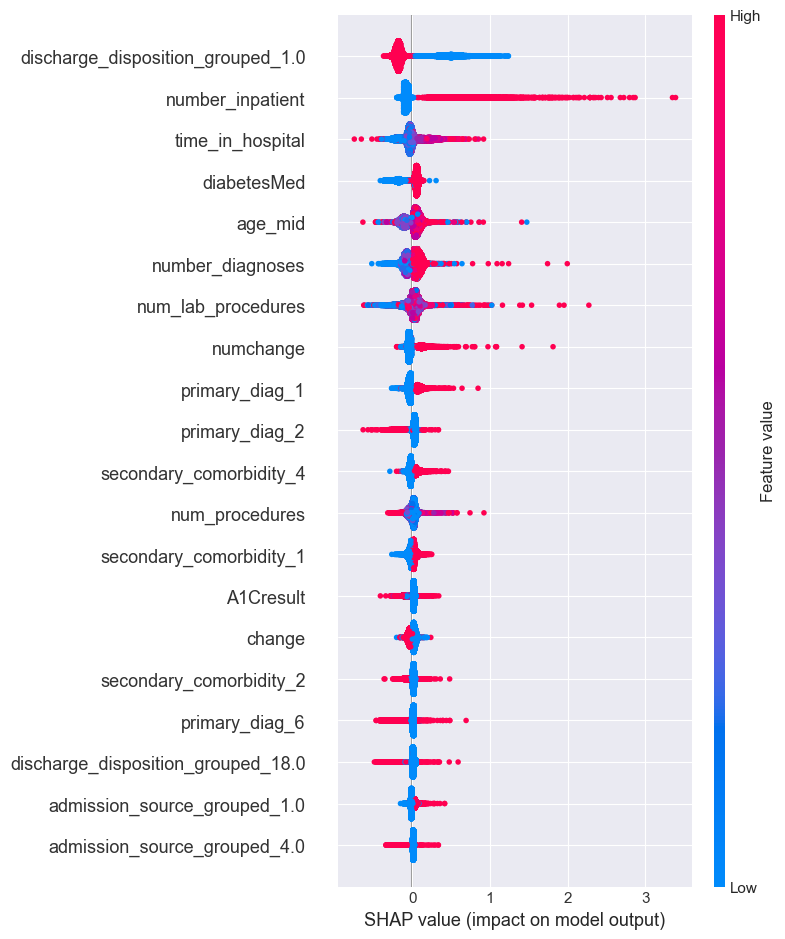

✓ SHAP summary plot saved to ../results/shap_summary_stage2.png


In [39]:
# Visualize SHAP summary
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_train_stage1, max_display=20, show=False)
plt.tight_layout()
plt.savefig('../results/shap_summary_stage2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP summary plot saved to ../results/shap_summary_stage2.png")

In [40]:
# Select top K features based on SHAP importance
# You can adjust K based on your model complexity needs
K_FEATURES = 25  # Adjust this value as needed

final_selected_features = [feat for feat, _ in shap_ranking[:K_FEATURES]]

# Create final datasets from the ALREADY SCALED data
# Important: X_train_scaled, X_val_scaled, X_test_scaled were scaled using MinMaxScaler
# fitted on the training set only, so we're maintaining proper scaling here
X_train_final = X_train_scaled[final_selected_features].copy()
X_val_final = X_val_scaled[final_selected_features].copy()
X_test_final = X_test_scaled[final_selected_features].copy()

# Verify that continuous features are still properly scaled (should be in [0, 1] range for MinMaxScaler)
continuous_features_in_selection = [f for f in final_selected_features if f in continuous_features_to_scale]
if continuous_features_in_selection:
    print(f"\n{'='*70}")
    print(f"SCALING VERIFICATION")
    print(f"{'='*70}")
    print(f"Continuous features in final selection: {len(continuous_features_in_selection)}")
    print(f"\nVerifying scaling is preserved (MinMaxScaler range: [0, 1]):")
    for feat in continuous_features_in_selection[:5]:  # Show first 5
        train_min, train_max = X_train_final[feat].min(), X_train_final[feat].max()
        val_min, val_max = X_val_final[feat].min(), X_val_final[feat].max()
        test_min, test_max = X_test_final[feat].min(), X_test_final[feat].max()
        print(f"  {feat}:")
        print(f"    Train: [{train_min:.4f}, {train_max:.4f}]")
        print(f"    Val:   [{val_min:.4f}, {val_max:.4f}]")
        print(f"    Test:  [{test_min:.4f}, {test_max:.4f}]")
    if len(continuous_features_in_selection) > 5:
        print(f"  ... and {len(continuous_features_in_selection) - 5} more continuous features")
    print(f"✓ All continuous features maintain proper scaling")
    print(f"{'='*70}\n")

print(f"\n{'='*70}")
print(f"FINAL FEATURE SELECTION SUMMARY")
print(f"{'='*70}")
print(f"Original features: {X_train_scaled.shape[1]}")
print(f"After Stage 1 (LASSO): {len(selected_features_stage1)}")
print(f"After Stage 2 (SHAP top-{K_FEATURES}): {len(final_selected_features)}")
print(f"\nReduction: {X_train_scaled.shape[1]} → {len(final_selected_features)} features")
print(f"Compression ratio: {len(final_selected_features)/X_train_scaled.shape[1]:.1%}")
print(f"\n✓ Final datasets created:")
print(f"  Training: {X_train_final.shape}")
print(f"  Validation: {X_val_final.shape}")
print(f"  Test: {X_test_final.shape}")
print(f"{'='*70}")


SCALING VERIFICATION
Continuous features in final selection: 7

Verifying scaling is preserved (MinMaxScaler range: [0, 1]):
  number_inpatient:
    Train: [0.0000, 1.0000]
    Val:   [0.0000, 1.0000]
    Test:  [0.0000, 0.8333]
  time_in_hospital:
    Train: [0.0000, 1.0000]
    Val:   [0.0000, 1.0000]
    Test:  [0.0000, 1.0000]
  age_mid:
    Train: [0.0000, 1.0000]
    Val:   [0.0000, 1.0000]
    Test:  [0.0000, 1.0000]
  number_diagnoses:
    Train: [0.0000, 1.0000]
    Val:   [0.0000, 1.0000]
    Test:  [0.0000, 1.0000]
  num_lab_procedures:
    Train: [0.0000, 1.0000]
    Val:   [0.0000, 0.8397]
    Test:  [0.0000, 0.9084]
  ... and 2 more continuous features
✓ All continuous features maintain proper scaling


FINAL FEATURE SELECTION SUMMARY
Original features: 57
After Stage 1 (LASSO): 33
After Stage 2 (SHAP top-25): 25

Reduction: 57 → 25 features
Compression ratio: 43.9%

✓ Final datasets created:
  Training: (40251, 25)
  Validation: (13417, 25)
  Test: (13418, 25)


### Do some additional Statistical Corrections

In [41]:
# Analyze skewness and kurtosis in final selected features
from scipy import stats

print(f"\n{'='*70}")
print(f"SKEWNESS AND KURTOSIS ANALYSIS - FINAL SELECTED FEATURES")
print(f"{'='*70}")

# Analyze continuous features in the final selection
continuous_in_final = [f for f in final_selected_features if f in continuous_features_to_scale]

if continuous_in_final:
    print(f"\nAnalyzing {len(continuous_in_final)} continuous features:")
    print(f"\n{'Feature':<35} {'Skewness':>10} {'Kurtosis':>10} {'Status':>12}")
    print("-" * 70)

    high_skew_features = []
    for feat in continuous_in_final:
        skew = X_train_final[feat].skew()
        kurt = X_train_final[feat].kurtosis()

        # Flag if |skewness| > 0.5 or |kurtosis| > 3
        status = "OK"
        if abs(skew) > 1.0 or abs(kurt) > 3:
            status = "HIGH"
            high_skew_features.append(feat)
        elif abs(skew) > 0.5:
            status = "MODERATE"

        print(f"{feat:<35} {skew:>10.3f} {kurt:>10.3f} {status:>12}")

    print("-" * 70)
    print(f"\nFeatures with high skewness/kurtosis: {len(high_skew_features)}")
    if high_skew_features:
        print("These features may benefit from transformation:")
        for feat in high_skew_features:
            print(f"  - {feat}")
else:
    print("\nNo continuous features in final selection - skipping analysis")

print(f"{'='*70}\n")


SKEWNESS AND KURTOSIS ANALYSIS - FINAL SELECTED FEATURES

Analyzing 7 continuous features:

Feature                               Skewness   Kurtosis       Status
----------------------------------------------------------------------
number_inpatient                         5.138     39.210         HIGH
time_in_hospital                         1.172      0.986         HIGH
age_mid                                 -0.571      0.155     MODERATE
number_diagnoses                        -0.658     -0.586     MODERATE
num_lab_procedures                      -0.226     -0.310           OK
numchange                                1.639      2.306         HIGH
num_procedures                           1.219      0.546         HIGH
----------------------------------------------------------------------

Features with high skewness/kurtosis: 4
These features may benefit from transformation:
  - number_inpatient
  - time_in_hospital
  - numchange
  - num_procedures



In [42]:
# Apply transformations to reduce skewness and kurtosis
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

print(f"\n{'='*70}")
print(f"APPLYING TRANSFORMATIONS TO REDUCE SKEWNESS/KURTOSIS")
print(f"{'='*70}")

# Create copies of the final datasets
X_train_final_transformed = X_train_final.copy()
X_val_final_transformed = X_val_final.copy()
X_test_final_transformed = X_test_final.copy()

# Identify continuous features in final selection
continuous_in_final = [f for f in final_selected_features if f in continuous_features_to_scale]

if continuous_in_final:
    print(f"\nTransforming {len(continuous_in_final)} continuous features using Yeo-Johnson power transform...")
    print("(This transformation handles zero/negative values and reduces skewness)\n")

    # Use PowerTransformer with Yeo-Johnson (handles zeros and negative values)
    # This is better than Box-Cox for data with zeros
    power_transformer = PowerTransformer(method='yeo-johnson', standardize=True)

    # Fit on training data only
    X_train_final_transformed[continuous_in_final] = power_transformer.fit_transform(
        X_train_final[continuous_in_final]
    )

    # Transform validation and test sets
    X_val_final_transformed[continuous_in_final] = power_transformer.transform(
        X_val_final[continuous_in_final]
    )

    X_test_final_transformed[continuous_in_final] = power_transformer.transform(
        X_test_final[continuous_in_final]
    )

    # Show before/after comparison
    print(f"{'Feature':<35} {'Before Skew':>12} {'After Skew':>12} {'Improvement':>12}")
    print("-" * 75)

    for feat in continuous_in_final:
        skew_before = X_train_final[feat].skew()
        skew_after = X_train_final_transformed[feat].skew()
        improvement = abs(skew_before) - abs(skew_after)

        arrow = "✓" if improvement > 0 else "→"
        print(f"{feat:<35} {skew_before:>12.3f} {skew_after:>12.3f} {arrow:>4} {improvement:>7.3f}")

    print("-" * 75)

    # Summary statistics
    avg_skew_before = np.mean([abs(X_train_final[f].skew()) for f in continuous_in_final])
    avg_skew_after = np.mean([abs(X_train_final_transformed[f].skew()) for f in continuous_in_final])
    avg_kurt_before = np.mean([abs(X_train_final[f].kurtosis()) for f in continuous_in_final])
    avg_kurt_after = np.mean([abs(X_train_final_transformed[f].kurtosis()) for f in continuous_in_final])

    print(f"\nAverage |Skewness|:  {avg_skew_before:.3f} → {avg_skew_after:.3f} ({(avg_skew_after - avg_skew_before):.3f})")
    print(f"Average |Kurtosis|:  {avg_kurt_before:.3f} → {avg_kurt_after:.3f} ({(avg_kurt_after - avg_kurt_before):.3f})")

    print(f"\n✓ Transformed datasets created:")
    print(f"  Training: {X_train_final_transformed.shape}")
    print(f"  Validation: {X_val_final_transformed.shape}")
    print(f"  Test: {X_test_final_transformed.shape}")
else:
    print("\nNo continuous features to transform")
    X_train_final_transformed = X_train_final
    X_val_final_transformed = X_val_final
    X_test_final_transformed = X_test_final

print(f"{'='*70}\n")


APPLYING TRANSFORMATIONS TO REDUCE SKEWNESS/KURTOSIS

Transforming 7 continuous features using Yeo-Johnson power transform...
(This transformation handles zero/negative values and reduces skewness)

Feature                              Before Skew   After Skew  Improvement
---------------------------------------------------------------------------
number_inpatient                           5.138        2.272    ✓   2.866
time_in_hospital                           1.172        0.117    ✓   1.055
age_mid                                   -0.571       -0.057    ✓   0.514
number_diagnoses                          -0.658       -0.013    ✓   0.645
num_lab_procedures                        -0.226       -0.025    ✓   0.201
numchange                                  1.639        1.191    ✓   0.448
num_procedures                             1.219        0.301    ✓   0.918
---------------------------------------------------------------------------

Average |Skewness|:  1.518 → 0.568 (-0.950)
Ave

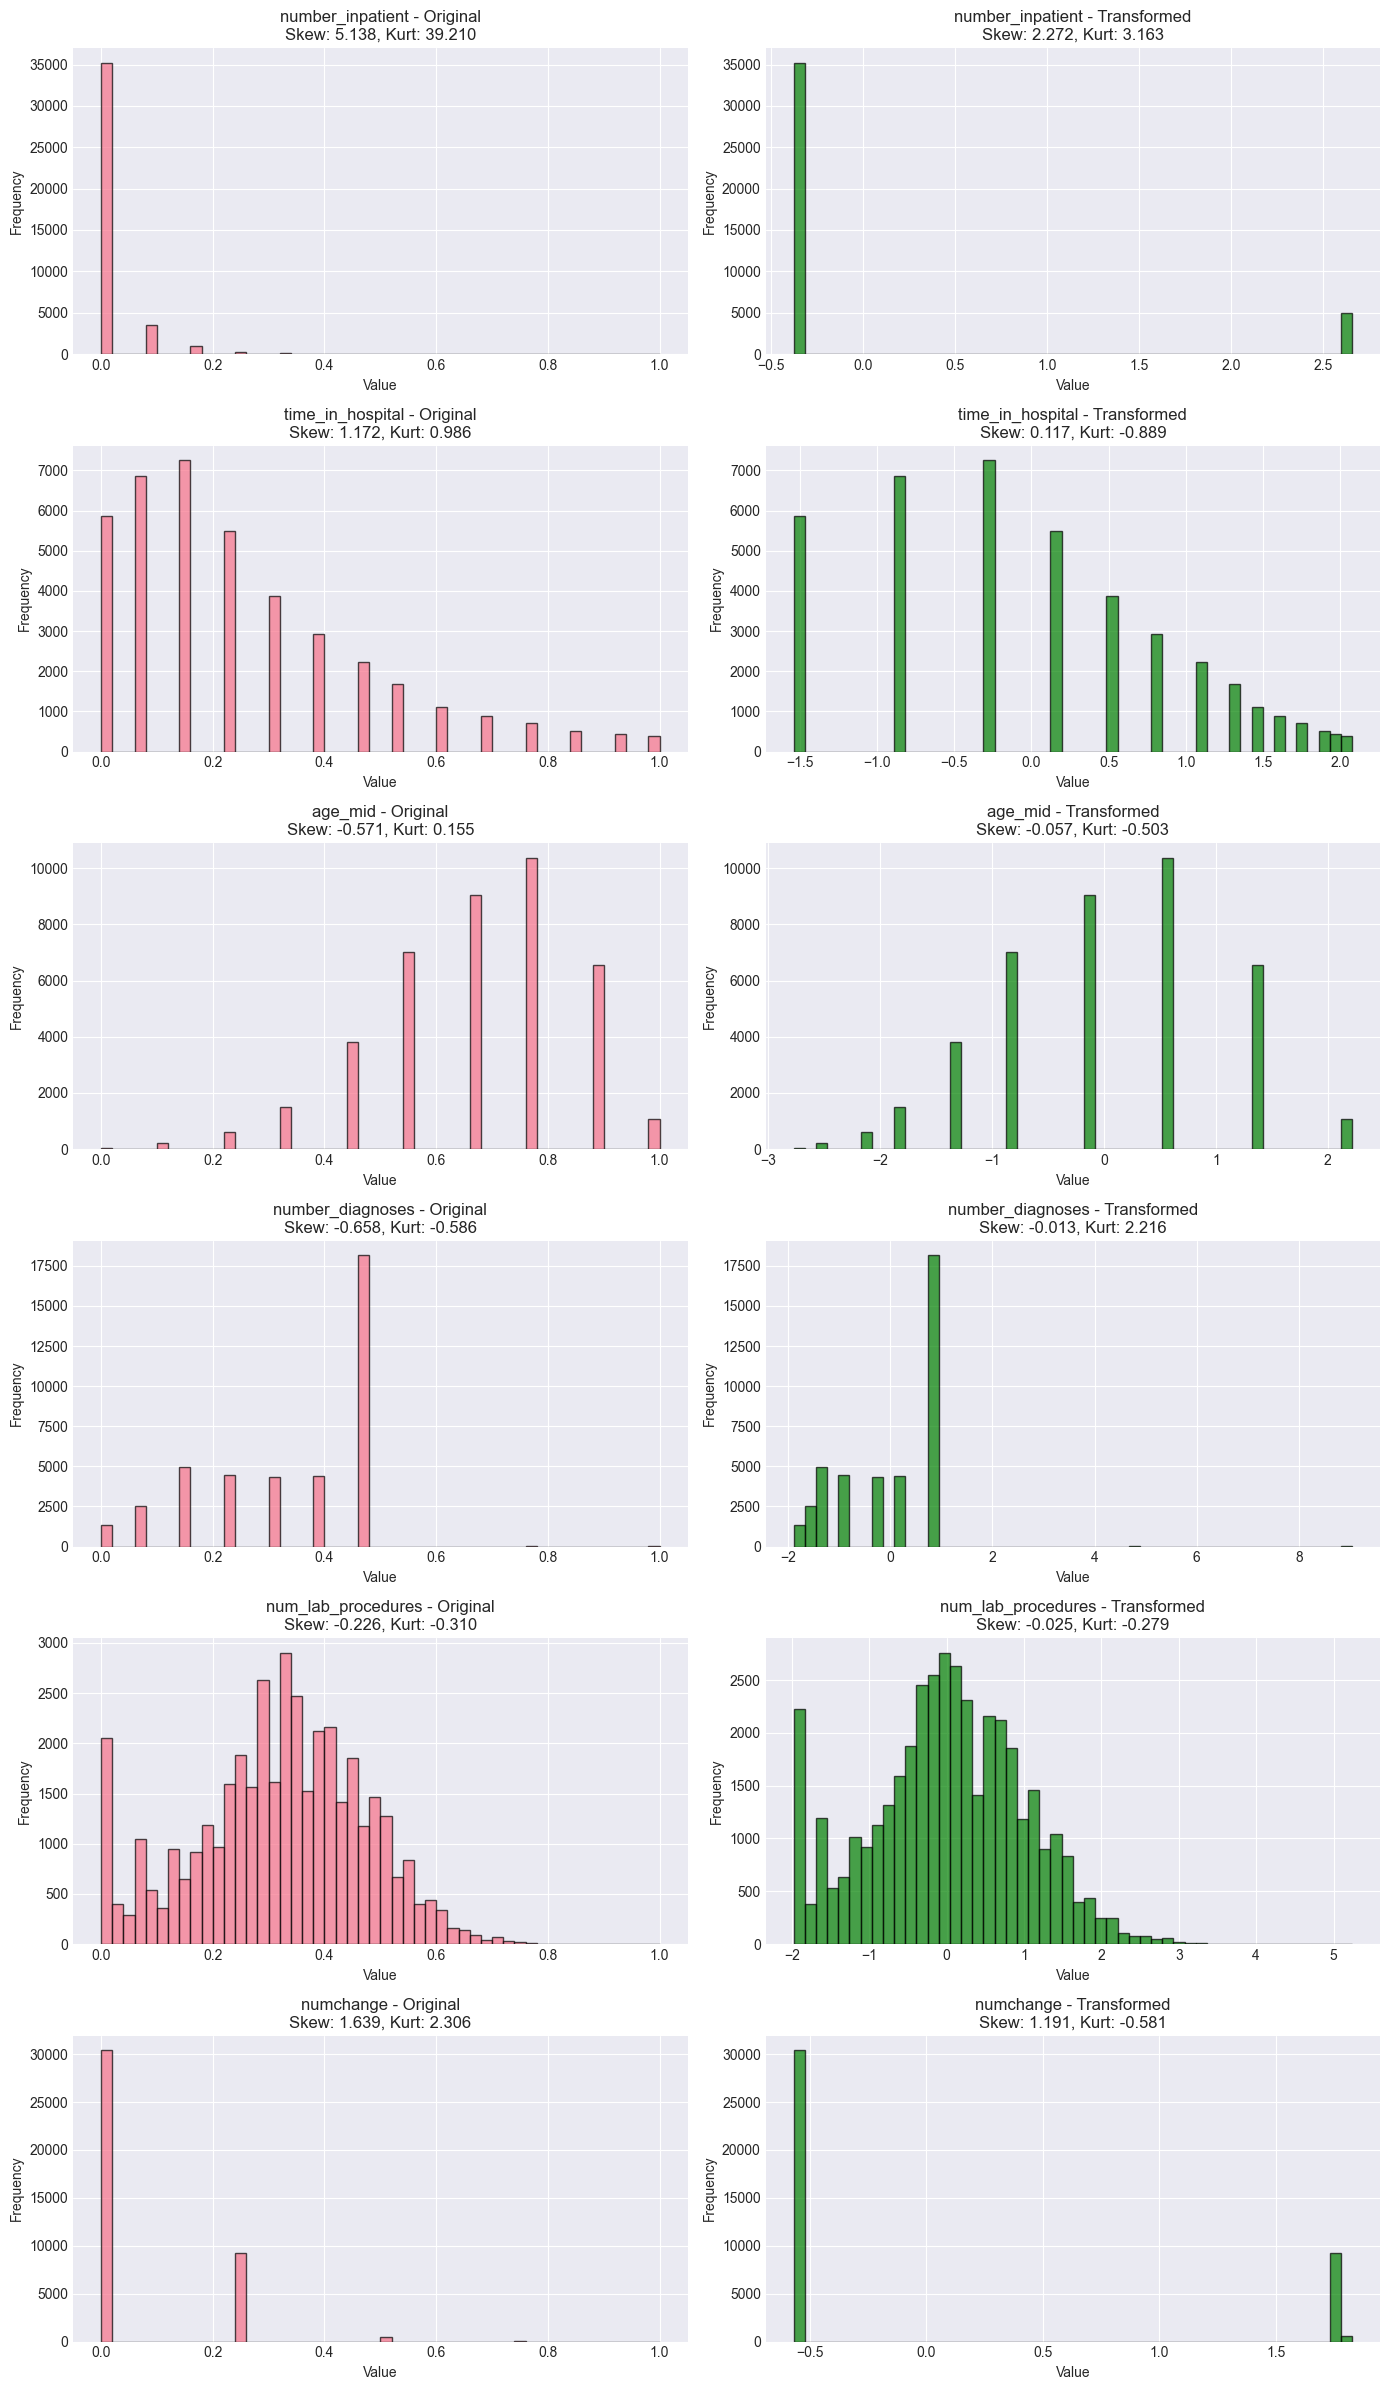

✓ Saved distribution comparison plot to ../results/distribution_transformation_comparison.png
  (Showing first 6 of 7 continuous features)


In [43]:
# Visualize distribution improvements
import matplotlib.pyplot as plt
import seaborn as sns

continuous_in_final = [f for f in final_selected_features if f in continuous_features_to_scale]

if continuous_in_final and len(continuous_in_final) > 0:
    # Select up to 6 features for visualization
    features_to_plot = continuous_in_final[:min(6, len(continuous_in_final))]

    fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(14, 4*len(features_to_plot)))
    if len(features_to_plot) == 1:
        axes = axes.reshape(1, -1)

    for idx, feat in enumerate(features_to_plot):
        # Before transformation
        axes[idx, 0].hist(X_train_final[feat], bins=50, edgecolor='black', alpha=0.7)
        axes[idx, 0].set_title(f'{feat} - Original\nSkew: {X_train_final[feat].skew():.3f}, Kurt: {X_train_final[feat].kurtosis():.3f}')
        axes[idx, 0].set_xlabel('Value')
        axes[idx, 0].set_ylabel('Frequency')

        # After transformation
        axes[idx, 1].hist(X_train_final_transformed[feat], bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[idx, 1].set_title(f'{feat} - Transformed\nSkew: {X_train_final_transformed[feat].skew():.3f}, Kurt: {X_train_final_transformed[feat].kurtosis():.3f}')
        axes[idx, 1].set_xlabel('Value')
        axes[idx, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.savefig('../results/distribution_transformation_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved distribution comparison plot to ../results/distribution_transformation_comparison.png")
    if len(continuous_in_final) > 6:
        print(f"  (Showing first 6 of {len(continuous_in_final)} continuous features)")
else:
    print("No continuous features to visualize")

In [44]:
# Save the feature-selected datasets (both original and transformed)
print("\nSaving feature-selected datasets...")

# Save Stage 1 (LASSO-selected) datasets
X_train_stage1.to_csv("../data/X_train_lasso_selected.csv", index=False)
X_val_stage1.to_csv("../data/X_val_lasso_selected.csv", index=False)
X_test_stage1.to_csv("../data/X_test_lasso_selected.csv", index=False)

# Save Stage 2 (SHAP-refined) datasets - ORIGINAL SCALING
X_train_final.to_csv("../data/X_train_final_selected.csv", index=False)
X_val_final.to_csv("../data/X_val_final_selected.csv", index=False)
X_test_final.to_csv("../data/X_test_final_selected.csv", index=False)

# Save Stage 2 (SHAP-refined) datasets - TRANSFORMED (reduced skewness/kurtosis)
X_train_final_transformed.to_csv("../data/X_train_final_selected_transformed.csv", index=False)
X_val_final_transformed.to_csv("../data/X_val_final_selected_transformed.csv", index=False)
X_test_final_transformed.to_csv("../data/X_test_final_selected_transformed.csv", index=False)

# Save feature lists and importance scores
feature_selection_info = {
    'lasso_selected_features': selected_features_stage1,
    'lasso_stability_scores': dict(zip(X_train_scaled.columns, stability_scores)),
    'final_selected_features': final_selected_features,
    'shap_importance': dict(zip(feature_names, shap_importance)),
    'continuous_features_transformed': [f for f in final_selected_features if f in continuous_features_to_scale],
    'transformation_method': 'yeo-johnson power transform'
}

import json
with open('../data/feature_selection_info.json', 'w') as f:
    json.dump(feature_selection_info, f, indent=2)

print("\n✓ Saved Stage 1 (LASSO) datasets:")
print(f"  - X_train_lasso_selected.csv: {X_train_stage1.shape}")
print(f"  - X_val_lasso_selected.csv: {X_val_stage1.shape}")
print(f"  - X_test_lasso_selected.csv: {X_test_stage1.shape}")

print("\n✓ Saved Stage 2 (Final - MinMaxScaled) datasets:")
print(f"  - X_train_final_selected.csv: {X_train_final.shape}")
print(f"  - X_val_final_selected.csv: {X_val_final.shape}")
print(f"  - X_test_final_selected.csv: {X_test_final.shape}")

print("\n✓ Saved Stage 2 (Final - Transformed, reduced skew/kurtosis) datasets:")
print(f"  - X_train_final_selected_transformed.csv: {X_train_final_transformed.shape}")
print(f"  - X_val_final_selected_transformed.csv: {X_val_final_transformed.shape}")
print(f"  - X_test_final_selected_transformed.csv: {X_test_final_transformed.shape}")

print("\n✓ Saved feature selection metadata:")
print(f"  - feature_selection_info.json")

print("\n" + "=" * 70)
print("FEATURE SELECTION COMPLETE")
print("=" * 70)
print("Available datasets:")
print("  1. Full dataset (X_train_scaled.csv) - All features, MinMax scaled")
print("  2. LASSO-selected (X_train_lasso_selected.csv) - Stable features")
print("  3. SHAP-refined (X_train_final_selected.csv) - Top predictive features")
print("=" * 70)


Saving feature-selected datasets...

✓ Saved Stage 1 (LASSO) datasets:
  - X_train_lasso_selected.csv: (40251, 33)
  - X_val_lasso_selected.csv: (13417, 33)
  - X_test_lasso_selected.csv: (13418, 33)

✓ Saved Stage 2 (Final - MinMaxScaled) datasets:
  - X_train_final_selected.csv: (40251, 25)
  - X_val_final_selected.csv: (13417, 25)
  - X_test_final_selected.csv: (13418, 25)

✓ Saved Stage 2 (Final - Transformed, reduced skew/kurtosis) datasets:
  - X_train_final_selected_transformed.csv: (40251, 25)
  - X_val_final_selected_transformed.csv: (13417, 25)
  - X_test_final_selected_transformed.csv: (13418, 25)

✓ Saved feature selection metadata:
  - feature_selection_info.json

FEATURE SELECTION COMPLETE
Available datasets:
  1. Full dataset (X_train_scaled.csv) - All features, MinMax scaled
  2. LASSO-selected (X_train_lasso_selected.csv) - Stable features
  3. SHAP-refined (X_train_final_selected.csv) - Top predictive features
